In [23]:
# CARGA DE DATOS #

import pandas as pd
import matplotlib.pyplot as plt
# test comment
# Ruta al archivo de Excel
archivo_excel = './IIYNT-REQ-BD-001.xlsx' #../

# Número de la fila desde la cual querés empezar (0-indexado)
fila_inicio = 3

# Leer el archivo Excel
init_df = pd.read_excel(archivo_excel)

# Mostrar las primeras filas del DataFrame para confirmar que se leyó bien
init_df.head()

# TRANSFORMACIÓN DE DATOS #

desired_columns = [
    'Temperatura Ambiental (°C)', 
    'Humedad',
    'Temperatura de la muestra (°C)', 
    'pH', 
    'CE\n(µS/cm)', 
    'STD\n(mg/L)',
    'STS\n(mL sed/L)', 
    'OD\n(mg/L)', 
    'Nivel (cm)', 
    'Turbidez (NTU)',
    'Dureza\n(mg CaCO3/L)', 
    'Cloruros\n(mg Cl-/L)'
]
df = init_df.iloc[2:272][desired_columns]
df


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
2,16,0.929,18,8.2,1240,610,NaN,5.37,NaN,NaN,NaN,NaN
3,17,0.47,19,8.3,1630,810,1.8,4.3,NaN,NaN,147,156
4,11.9,0.47,13,8.1,1000,490,18,5.3,NaN,41.2,94,78
5,11.9,0.47,13,8.2,1000,490,18,4.67,NaN,38.9,86,82
6,11.9,0.47,13,8.3,1350,670,0.1,7.01,NaN,30.7,200,117
...,...,...,...,...,...,...,...,...,...,...,...,...
267,11,0.51,13.1,8.1,1250,620,2,1.38,40,23.2,NaN,NaN
268,11,0.51,12.9,8.1,880,420,10,2.73,55,1.87,NaN,NaN
269,11,0.51,13.1,8.1,900,440,10,1.68,55,1.4,NaN,NaN
270,11,0.51,13,7.8,1070,530,20,1.32,55,31.5,NaN,NaN


In [24]:
#Eliminar las filas que tienen valores nulos o no asignados
#df.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true

#Si asigno a nueva variable no hace falta inplace=true pero no modifica el Dataframe original
df_sin_nulos=df.dropna()

#Como opcion puedo llenar los valores nulos con datos adecuados: 
#fillna(method='bfill') (llenar con el valor siguiente de la columna)
#fillna(method='ffill') (llenar con el valor anterior de la columna)
#fillna(0) (llenar con ceros) 

""" mediaNivel=df['Nivel (cm)'].mean()
df['Nivel (cm)']=df['Nivel (cm)'].fillna(mediaNivel)

mediaSTS=df['STS\n(mL sed/L)'].mean()
df['STS\n(mL sed/L)']=df['STS\n(mL sed/L)'].fillna(mediaSTS)

mediaTurbidez=df['Turbidez (NTU)'].mean()
df['Turbidez (NTU)']=df['Turbidez (NTU)'].fillna(mediaTurbidez)

mediaDureza=df['Dureza\n(mg CaCO3/L)'].mean()
df['Dureza\n(mg CaCO3/L)']=df['Dureza\n(mg CaCO3/L)'].fillna(mediaDureza)

mediaCloruros=df['Cloruros\n(mg Cl-/L)'].mean()
df['Cloruros\n(mg Cl-/L)']=df['Cloruros\n(mg Cl-/L)'].fillna(mediaCloruros)
"""
#df_sin_nulos=df
df_sin_nulos.isna().sum()
#df_sin_nulos.head()
df_sin_nulos

,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
42,18,0.6,17.75,7.9,1210,600,92,1.79,27.5,1000,114,97
43,18,0.6,18.05,7.7,1170,580,92,1.35,27.5,1000,114,95
44,18,0.6,18.15,8.1,1000,490,50,4.97,27.5,238,135,79
45,18,0.6,18.15,8.1,1000,490,50,3.12,27.5,351,139,81
46,18,0.6,18.2,8.2,1310,640,64,1.71,47.5,95.6,135,120
...,...,...,...,...,...,...,...,...,...,...,...,...
215,30.5,0.5,27.6,8.2,1570,780,30,0.96,30,10.6,223,166
216,30.5,0.5,27.6,8,1530,760,40,0.52,40,19.6,194,150
217,30.5,0.5,27.6,7.9,1530,760,40,0.47,40,21.3,194,150
218,30.5,0.5,27.6,7.8,1050,520,1,1.34,25,1.06,245,71


In [25]:
df_sin_nulos.describe()

,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
count,168,168.00,168.0,168.0,168,168,168,168.00,168,168,168,168
unique,18,16.00,76.0,15.0,84,53,37,137.00,15,143,57,57
top,18,0.52,27.6,8.1,1530,550,50,0.96,30,1000,228,64
freq,10,20.00,7.0,28.0,6,9,18,3.00,42,8,12,8


#### Histogramas de datos reales

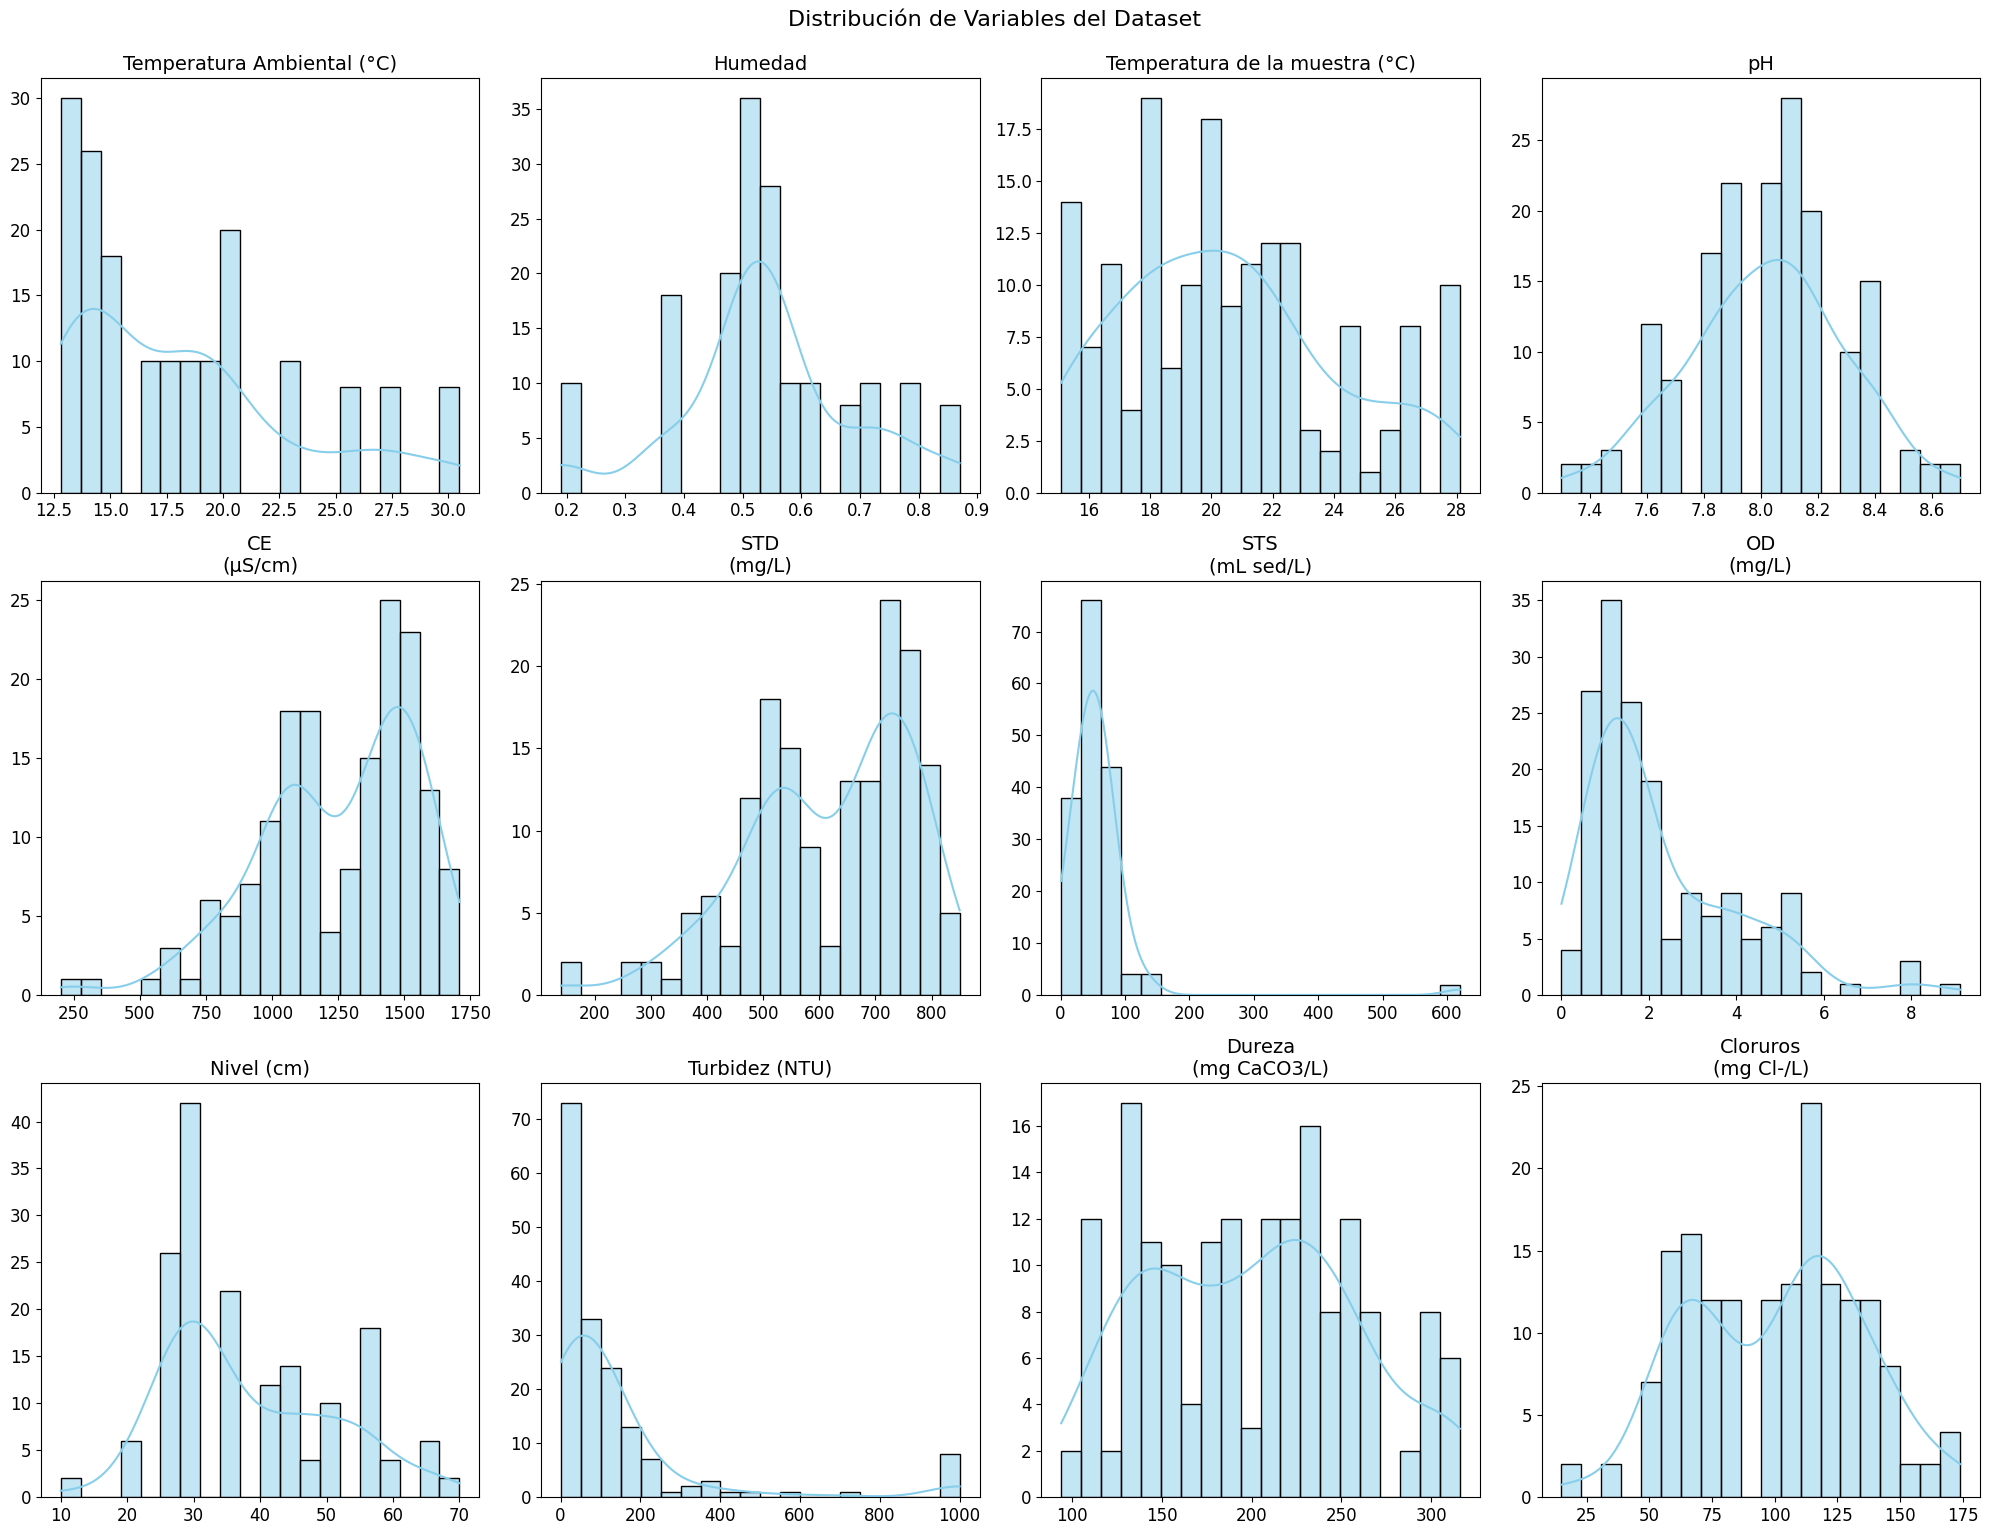

In [26]:

import seaborn as sns
import numpy as np

def plot_results(df: pd.DataFrame) -> None:
    """
    Función que grafica el histograma de cada columna del DataFrame
    """
    # Determinar el número de columnas en los datos
    n_cols = len(df.columns)

    # Calcular el número de filas necesarias para los subplots
    n_rows = int(np.ceil(n_cols / 4))

    # Crear una figura y una cuadrícula de subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(20, 5 * n_rows))

    # Aplanar el array de ejes para facilitar la indexación
    axes_flat = axes.flatten() if n_rows > 1 else axes

    # Eliminar cualquier subplot adicional
    for i in range(n_cols, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    # Crear histogramas
    for i, col in enumerate(df.columns):
        ax = axes_flat[i]
        sns.histplot(df[col], bins=20, color='skyblue', kde=True, ax=ax)
        ax.set_title(f'{col}', fontsize=14)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

    # Mejorar el diseño
    plt.tight_layout()
    plt.suptitle('Distribución de Variables del Dataset', fontsize=16, y=1.02)
    plt.show()

# Llamar a la función para mostrar los histogramas agrupados
plot_results(df_sin_nulos)


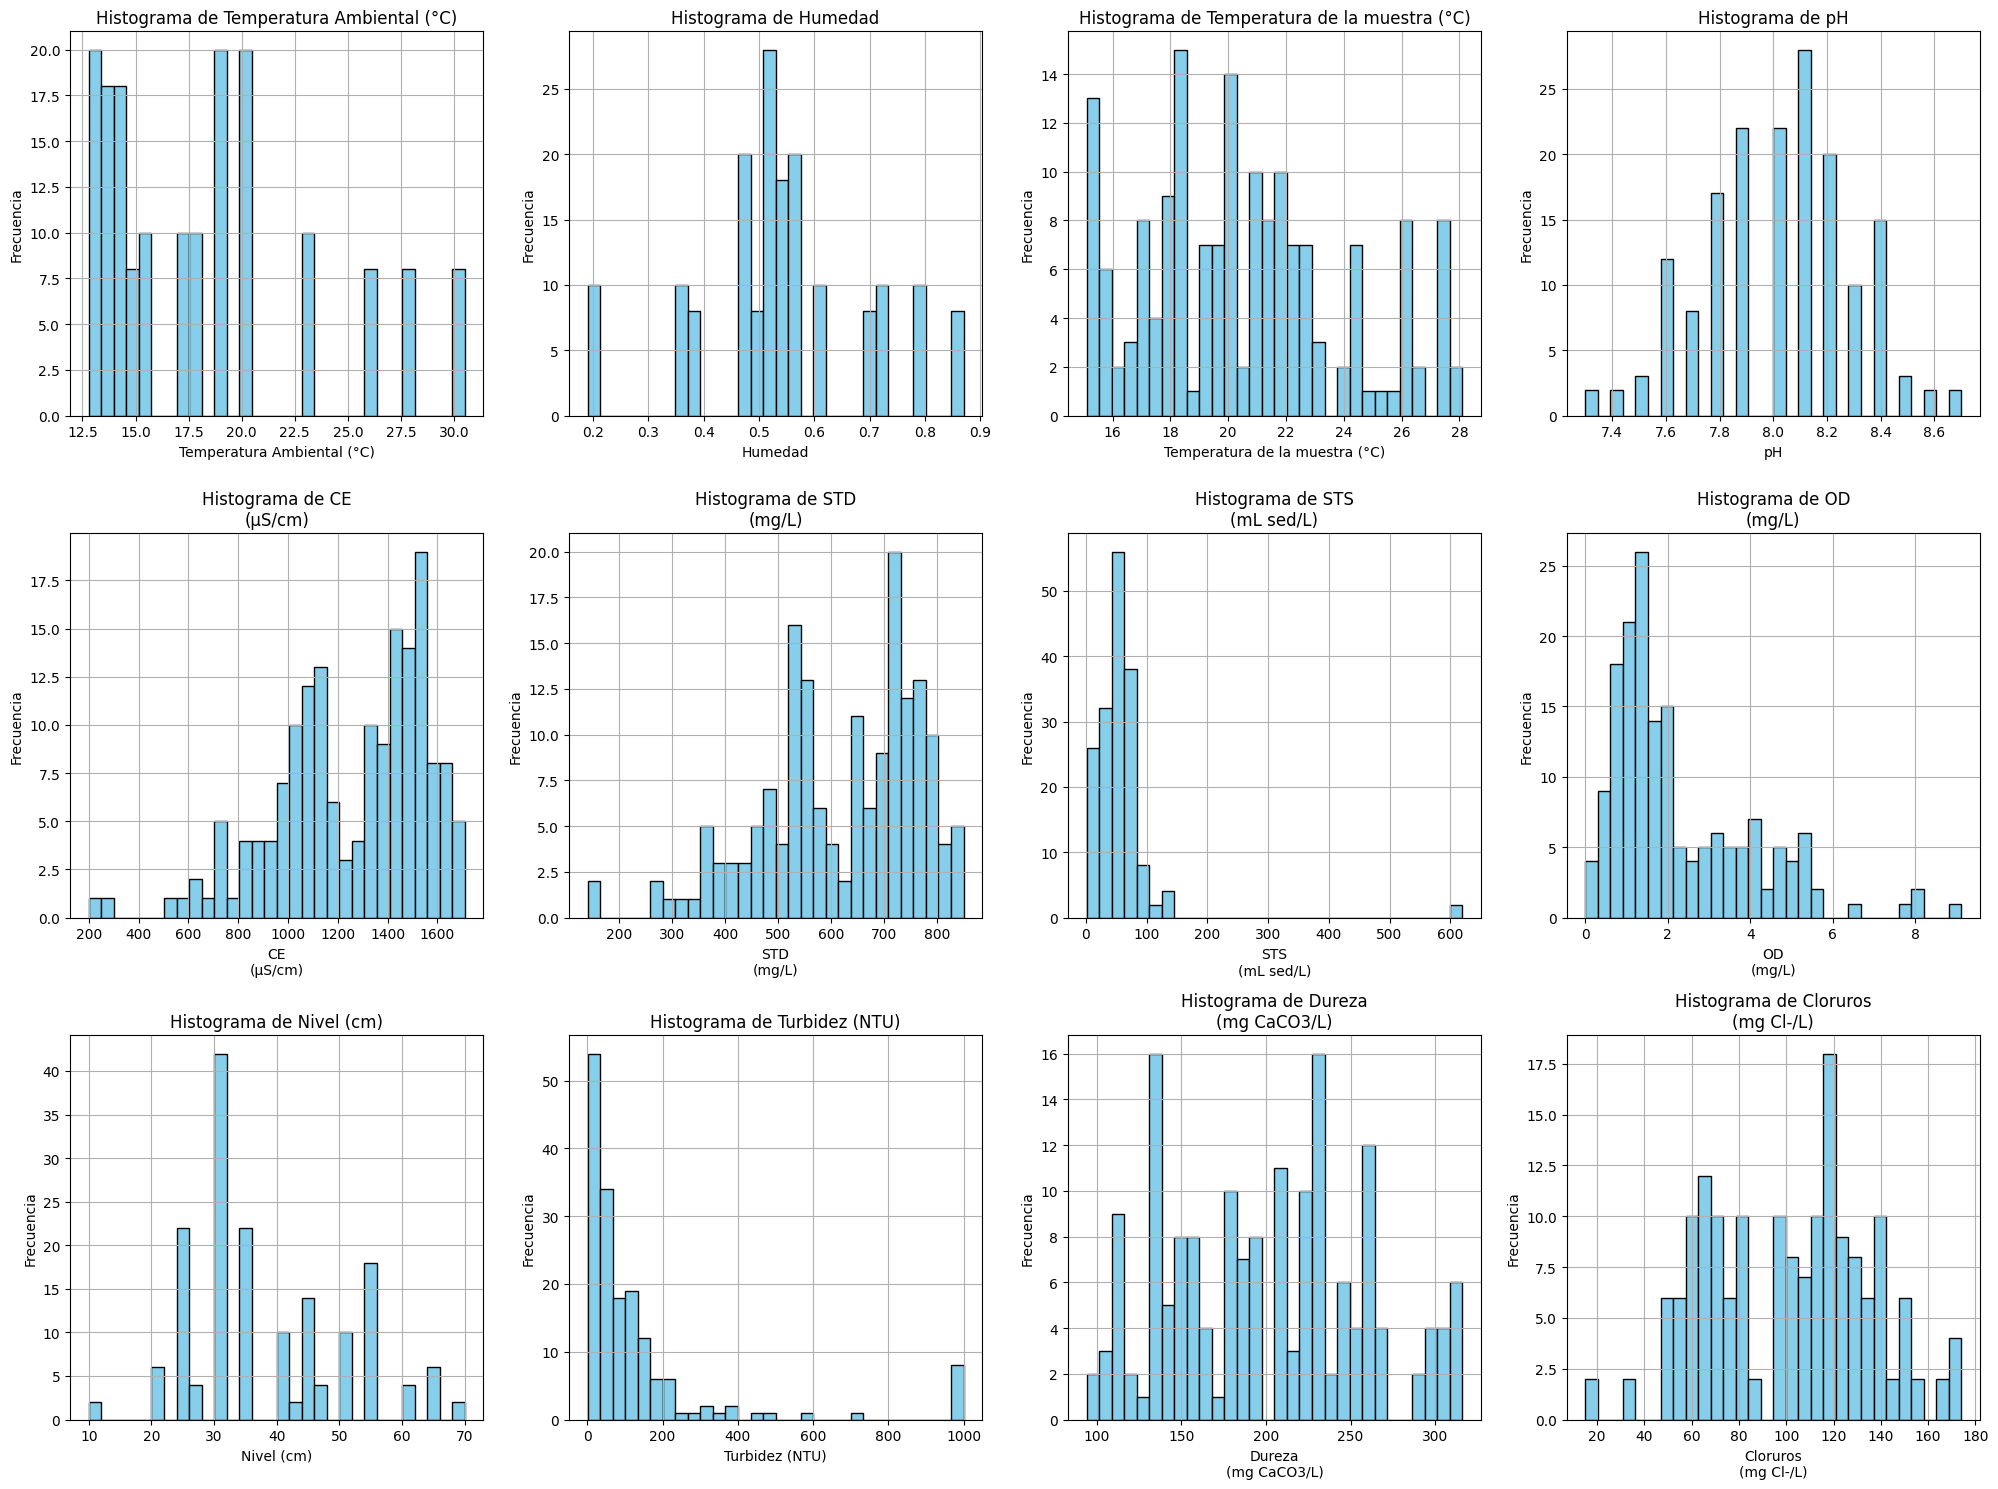

In [27]:

def mostrar_histogramas_agrupados(df):
    # Configuración del tamaño de la figura y el número de subplots
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
    axes = axes.flatten()  # Aplanar la matriz de ejes para un acceso más fácil

    # Iterar sobre las columnas y los ejes
    for i, column in enumerate(df.columns):
        axes[i].hist(df[column], bins=30, edgecolor='black', color='skyblue')
        axes[i].set_title(f'Histograma de {column}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frecuencia')
        axes[i].grid(True)

    # Ajustar el diseño para evitar la superposición de gráficos
    plt.tight_layout()
    plt.show()

# Llamar a la función para mostrar los histogramas agrupados
mostrar_histogramas_agrupados(df_sin_nulos)


In [28]:
def min_max_info(dataframe: pd.DataFrame) -> pd.DataFrame:
    name = list()
    minimums = list()
    maximums = list()
    median = list()
    std = list()
    for i, key in enumerate(dataframe.columns):
        name.append(key)
        minimums.append(dataframe[key].min())
        maximums.append(dataframe[key].max())
        median.append(dataframe[key].median())
        std.append(dataframe[key].std())
        
    return pd.DataFrame(
        {
            'name': name,
            'mins': minimums,
            'maxs': maximums,
            'median': median,
            'std': std
        }
    )
min_max_info(df_sin_nulos)

,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),12.80,30.50,17.50,4.966244
1,Humedad,0.19,0.87,0.53,0.152159
2,Temperatura de la muestra (°C),15.10,28.10,20.05,3.470633
3,pH,7.30,8.70,8.00,0.276488
4,CE\n(µS/cm),200.00,1710.00,1330.00,296.218678
5,STD\n(mg/L),140.00,850.00,655.00,146.845744
6,STS\n(mL sed/L),1.00,620.00,50.00,67.352935
7,OD\n(mg/L),0.00,9.12,1.67,1.755272
8,Nivel (cm),10.00,70.00,35.00,12.640534
9,Turbidez (NTU),1.06,1000.00,64.45,220.822212


In [29]:
def normalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return (dataframe - min) / (max - min)

def denormalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return dataframe * (max - min) + min


def normalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = normalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = normalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = normalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = normalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = normalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = normalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = normalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = normalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = normalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = normalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = normalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df

def denormalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = denormalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = denormalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = denormalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = denormalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = denormalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = denormalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = denormalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = denormalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = denormalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = denormalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = denormalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df




### Autoencoder basico

In [30]:
from keras.layers import Input, Dense
from keras.activations import sigmoid, tanh
from keras.models import Model
import numpy as np
from tensorflow.keras.callbacks import TensorBoard
import shutil
import os as os

try:
    shutil.rmtree('./.logs')
except FileNotFoundError:
    pass
os.mkdir('./.logs')
vector_size = len(df_sin_nulos.columns)
dataset = np.array(
    normalizer(df_sin_nulos).astype(np.float16)
)
encoded_size = 6

input_layer = Input(shape=(vector_size, )) 

x = Dense(32, activation=sigmoid)(input_layer)
x = Dense(32, activation=sigmoid)(x)

encoded = Dense(encoded_size, activation=sigmoid)(x)
x = Dense(32, activation=sigmoid)(encoded)
x = Dense(32, activation=sigmoid)(x)
output = Dense(vector_size, activation=sigmoid)(x)

autoencoder = Model(input_layer, output) # creo un modelo a partir de lo definido arriba
autoencoder.compile(optimizer='adam', loss='mse') # se compila el modelo
autoencoder.summary() # se imprime un resumen


Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 12)]              0         
                                                                 
 dense_20 (Dense)            (None, 32)                416       
                                                                 
 dense_21 (Dense)            (None, 32)                1056      
                                                                 
 dense_22 (Dense)            (None, 6)                 198       
                                                                 
 dense_23 (Dense)            (None, 32)                224       
                                                                 
 dense_24 (Dense)            (None, 32)                1056      
                                                                 
 dense_25 (Dense)            (None, 12)                396 

## Autoencoder variacional: Un valor entre otros dos valores es correctamente interpolado
### El dataset creado a partir del espacio latente generara valores coherentes.

In [31]:
from keras.layers import Input, Dense, Lambda
from keras.models import Model
from keras import backend as K
from keras.losses import mean_squared_error
import tensorflow as tf

# Definición de la capa de muestreo
def sampling(args):
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

# Supongamos que vector_size ya está definido
# vector_size = ...
encoded_size = 6  # Tamaño de la representación codificada (menor que 12)

input_layer = Input(shape=(vector_size,))
encoder_size = 32  # Tamaño de las capas del codificador y decodificador

# Encoder
x = Dense(encoder_size, activation='relu')(input_layer)  # Cambiado a 'relu'
x = Dense(encoder_size, activation='relu')(x)  # Cambiado a 'relu'

# Capas para z_mean y z_log_var
z_mean = Dense(encoded_size)(x)  # Tamaño reducido
z_log_var = Dense(encoded_size)(x)  # Tamaño reducido

# Capa de muestreo
z = Lambda(sampling, output_shape=(encoded_size,))([z_mean, z_log_var])

# Decoder
decoder_h1 = Dense(encoder_size, activation='relu')  # Cambiado a 'relu'
decoder_h2 = Dense(encoder_size, activation='relu')  # Cambiado a 'relu'
decoder_output = Dense(vector_size, activation='sigmoid')  # Capa de salida

# Reconstrucción
x_decoded = decoder_h1(z)
x_decoded = decoder_h2(x_decoded)
x_decoded = decoder_output(x_decoded)

# Modelo completo
vae = Model(input_layer, x_decoded)

# Función de pérdida personalizada
xent_loss = vector_size * mean_squared_error(input_layer, x_decoded)
kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
vae_loss = K.mean(xent_loss + kl_loss)

vae.add_loss(vae_loss)
vae.compile(optimizer='adam')

vae.summary()


Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 12)]                 0         []                            
                                                                                                  
 dense_26 (Dense)            (None, 32)                   416       ['input_6[0][0]']             
                                                                                                  
 dense_27 (Dense)            (None, 32)                   1056      ['dense_26[0][0]']            
                                                                                                  
 dense_28 (Dense)            (None, 6)                    198       ['dense_27[0][0]']            
                                                                                            

##lo hecho antes

In [32]:
from keras.layers import Input, Dense, Lambda
from keras.models import Model
from keras import backend as K
from keras.losses import mean_squared_error
import tensorflow as tf

# Definición de la capa de muestreo
def sampling(args):
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

# Supongamos que vector_size y encoded_size ya están definidos
# vector_size = ...
# encoded_size = ...

input_layer = Input(shape=(vector_size,))
encoder_size = 32
# Encoder
x = Dense(encoder_size, activation=sigmoid)(input_layer)
x = Dense(encoder_size, activation=sigmoid)(x)

z_mean = Dense(encoder_size)(x)
z_log_var = Dense(encoder_size)(x)

# Capa de muestreo
z = Lambda(sampling, output_shape=(encoder_size,))([z_mean, z_log_var])

# Decoder
decoder_h1 = Dense(encoder_size, activation=sigmoid)
decoder_h2 = Dense(encoder_size, activation=sigmoid)
decoder_output = Dense(vector_size, activation=sigmoid)

x_decoded = decoder_h1(z)
x_decoded = decoder_h2(x_decoded)
x_decoded = decoder_output(x_decoded)

# Modelo completo
vae = Model(input_layer, x_decoded)

# Función de pérdida personalizada
xent_loss = vector_size * mean_squared_error(input_layer, x_decoded)
kl_loss = - 0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
vae_loss = K.mean(xent_loss + kl_loss)

vae.add_loss(vae_loss)
vae.compile(optimizer='adam')

vae.summary()


Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_7 (InputLayer)        [(None, 12)]                 0         []                            
                                                                                                  
 dense_33 (Dense)            (None, 32)                   416       ['input_7[0][0]']             
                                                                                                  
 dense_34 (Dense)            (None, 32)                   1056      ['dense_33[0][0]']            
                                                                                                  
 dense_35 (Dense)            (None, 32)                   1056      ['dense_34[0][0]']            
                                                                                            

In [33]:

tensorboard = TensorBoard(log_dir='./.logs') #creo instancia para guardar
epochs = 12000 #20000 cantidad de veces a entranar o pasos para realizar el descenso del gradiente
autoencoder.fit(
    x=dataset,
    y=dataset,
    epochs=epochs,
    batch_size=len(dataset), #tamaño del bloque de entrenamiento
    shuffle=True,
    verbose=0, # que no envie salidas
    callbacks=[tensorboard]
    
)
    


In [34]:
generator = Model(encoded, output) #va del vector de clasificacion hasta la salida
generator.summary()

Model: "model_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 6)]               0         
                                                                 
 dense_23 (Dense)            (None, 32)                224       
                                                                 
 dense_24 (Dense)            (None, 32)                1056      
                                                                 
 dense_25 (Dense)            (None, 12)                396       
                                                                 
Total params: 1676 (6.55 KB)
Trainable params: 1676 (6.55 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [35]:
encoder = Model(input_layer, z) #encoded para el basico #va desde el input a los datos codificados o clasificador
encoder.summary()

Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_7 (InputLayer)        [(None, 12)]                 0         []                            
                                                                                                  
 dense_33 (Dense)            (None, 32)                   416       ['input_7[0][0]']             
                                                                                                  
 dense_34 (Dense)            (None, 32)                   1056      ['dense_33[0][0]']            
                                                                                                  
 dense_35 (Dense)            (None, 32)                   1056      ['dense_34[0][0]']            
                                                                                            

In [36]:
amount = 10000 #cantidad de predicciones
generated = np.zeros(shape=(amount, vector_size))
params = np.random.rand(amount, encoded_size)
generated = generator.predict(params)
gen_df = pd.DataFrame(generated)
gen_df.columns = df_sin_nulos.columns
gen_df = denormalizer(gen_df)
gen_df.to_csv('./dataset_simulado_2_neuronas_variacional_p2.csv')
gen_df

  1/313 [..............................] - ETA: 15s

313/313 [==============================] - 0s 630us/step


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
0,9.631124,0.601325,15.827209,7.382475,780.313782,385.941254,14.896074,0.941213,50.701256,3.389096,306.818695,23.218090
1,16.874956,0.717101,17.849991,7.378310,720.546326,358.275177,12.270739,1.477451,37.729187,1.235360,363.712097,27.713675
2,20.470755,0.459073,15.702583,8.056711,1070.406494,520.208862,102.450066,2.864800,35.616333,691.359192,205.120407,143.263489
3,14.891724,0.531911,15.174225,8.458935,1241.974609,614.264465,76.616745,2.012042,61.392670,178.632812,114.763748,101.031067
4,26.538914,0.614973,22.623402,7.412526,730.338379,363.676270,16.823738,2.556955,9.737845,1.167977,299.648926,66.751442
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,14.261190,0.646511,24.924953,7.682980,1159.506104,576.790039,40.120575,1.091013,29.012526,43.184242,171.234375,128.398270
9996,22.144087,0.469276,19.704987,7.851975,1022.061096,498.326355,90.467293,1.915555,23.480545,823.480530,231.341919,141.882111
9997,21.037607,0.572217,31.507332,8.107317,1420.129150,704.242371,46.308788,1.683406,40.062340,213.766129,183.361786,145.947266
9998,8.945418,0.454760,20.941910,7.043633,455.096191,238.090973,34.380993,3.586248,22.792015,94.643188,334.760223,60.938133


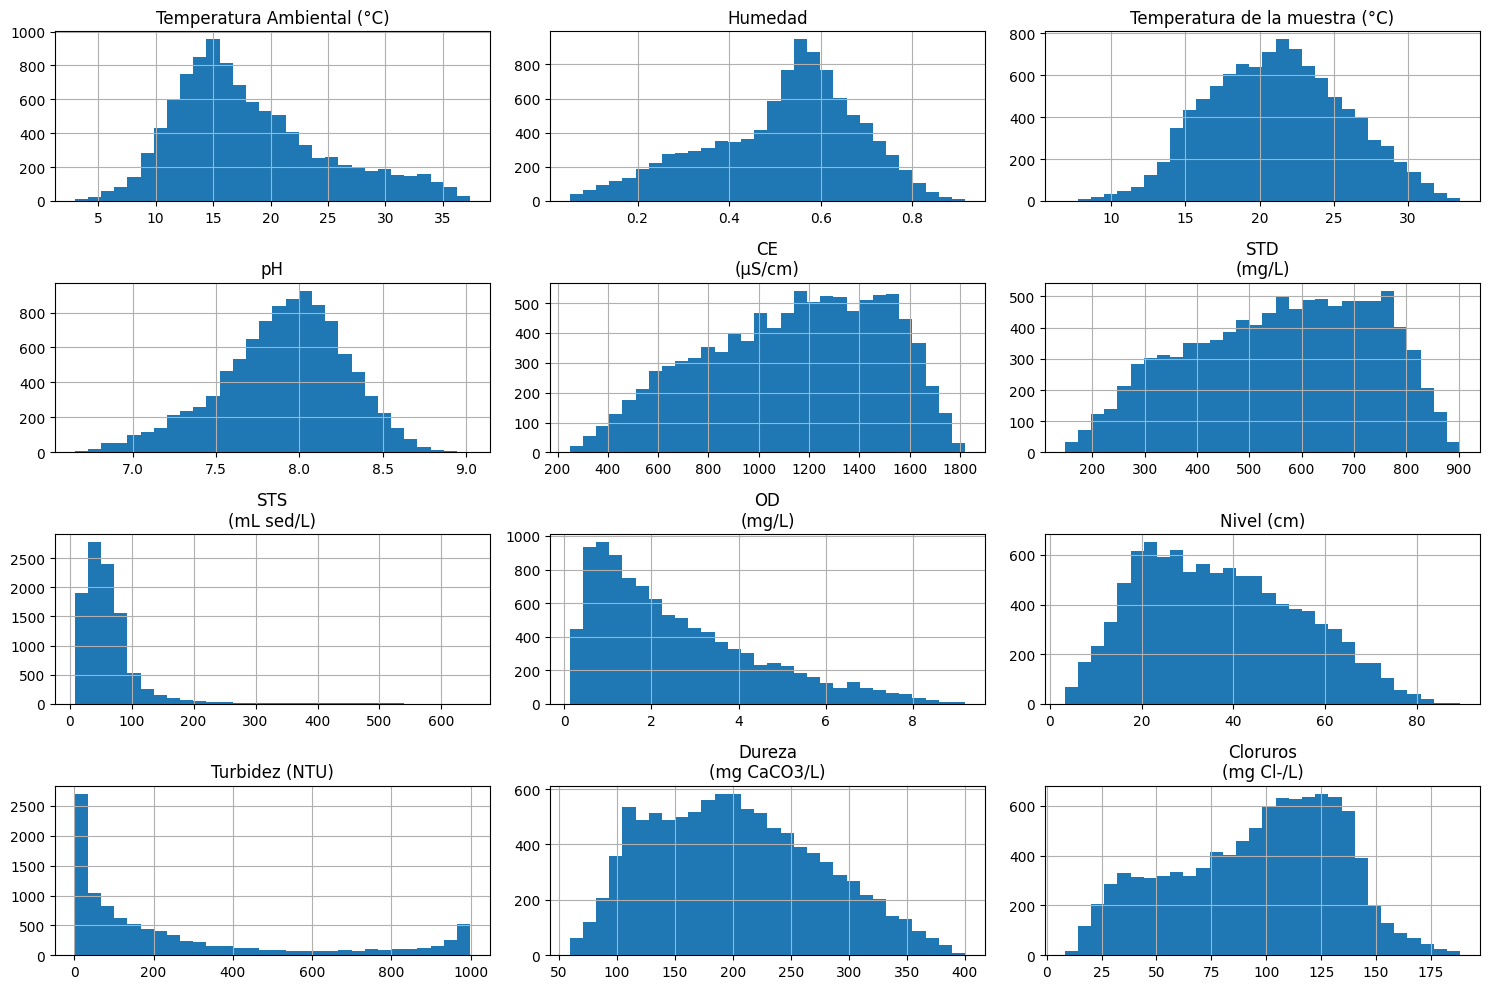

In [37]:
def plot_histograms(df, bins=30, figsize=(15, 10)):
    """
    Genera histogramas para cada columna del DataFrame.
    
    Parámetros:
    df (DataFrame): El DataFrame con los datos a visualizar.
    bins (int): Número de bins para los histogramas.
    figsize (tuple): Tamaño de la figura para los histogramas.
    """
    df.hist(bins=bins, figsize=figsize)
    plt.tight_layout()
    plt.show()

# Llamada a la función con el DataFrame generado
plot_histograms(gen_df)

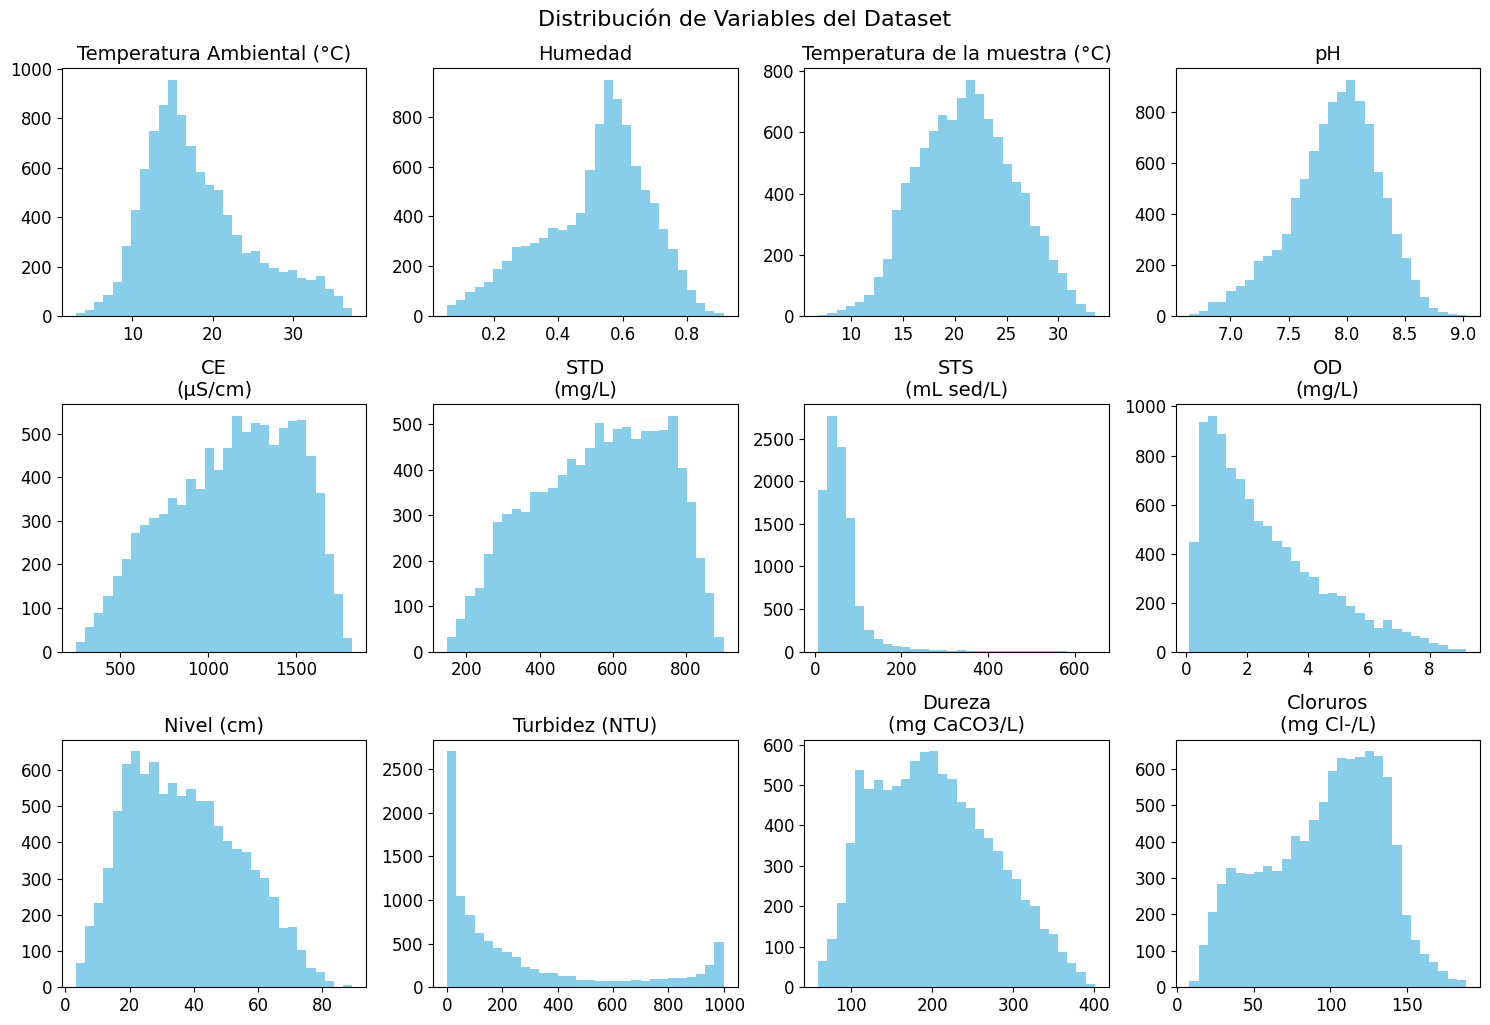

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_results(df: pd.DataFrame, bins: int = 30, figsize: tuple = (15, 10)) -> None:
    """
    Función que grafica el histograma de cada columna del DataFrame.
    
    Parámetros:
    df (DataFrame): El DataFrame con los datos a visualizar.
    bins (int): Número de bins para los histogramas.
    figsize (tuple): Tamaño de la figura para los histogramas.
    """
    # Determinar el número de columnas en los datos
    n_cols = len(df.columns)

    # Calcular el número de filas necesarias para los subplots
    n_rows = int(np.ceil(n_cols / 4))

    # Crear una figura y una cuadrícula de subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=figsize)

    # Aplanar el array de ejes para facilitar la indexación
    axes_flat = axes.flatten() if n_rows > 1 else axes

    # Eliminar cualquier subplot adicional
    for i in range(n_cols, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    # Crear histogramas
    for i, col in enumerate(df.columns):
        ax = axes_flat[i]
        df[col].plot(kind='hist', bins=bins, ax=ax, color='skyblue')
        ax.set_title(f'{col}', fontsize=14)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

    # Mejorar el diseño
    plt.tight_layout()
    plt.suptitle('Distribución de Variables del Dataset', fontsize=16, y=1.02)
    plt.show()

# Llamar a la función para mostrar los histogramas agrupados
plot_results(gen_df)


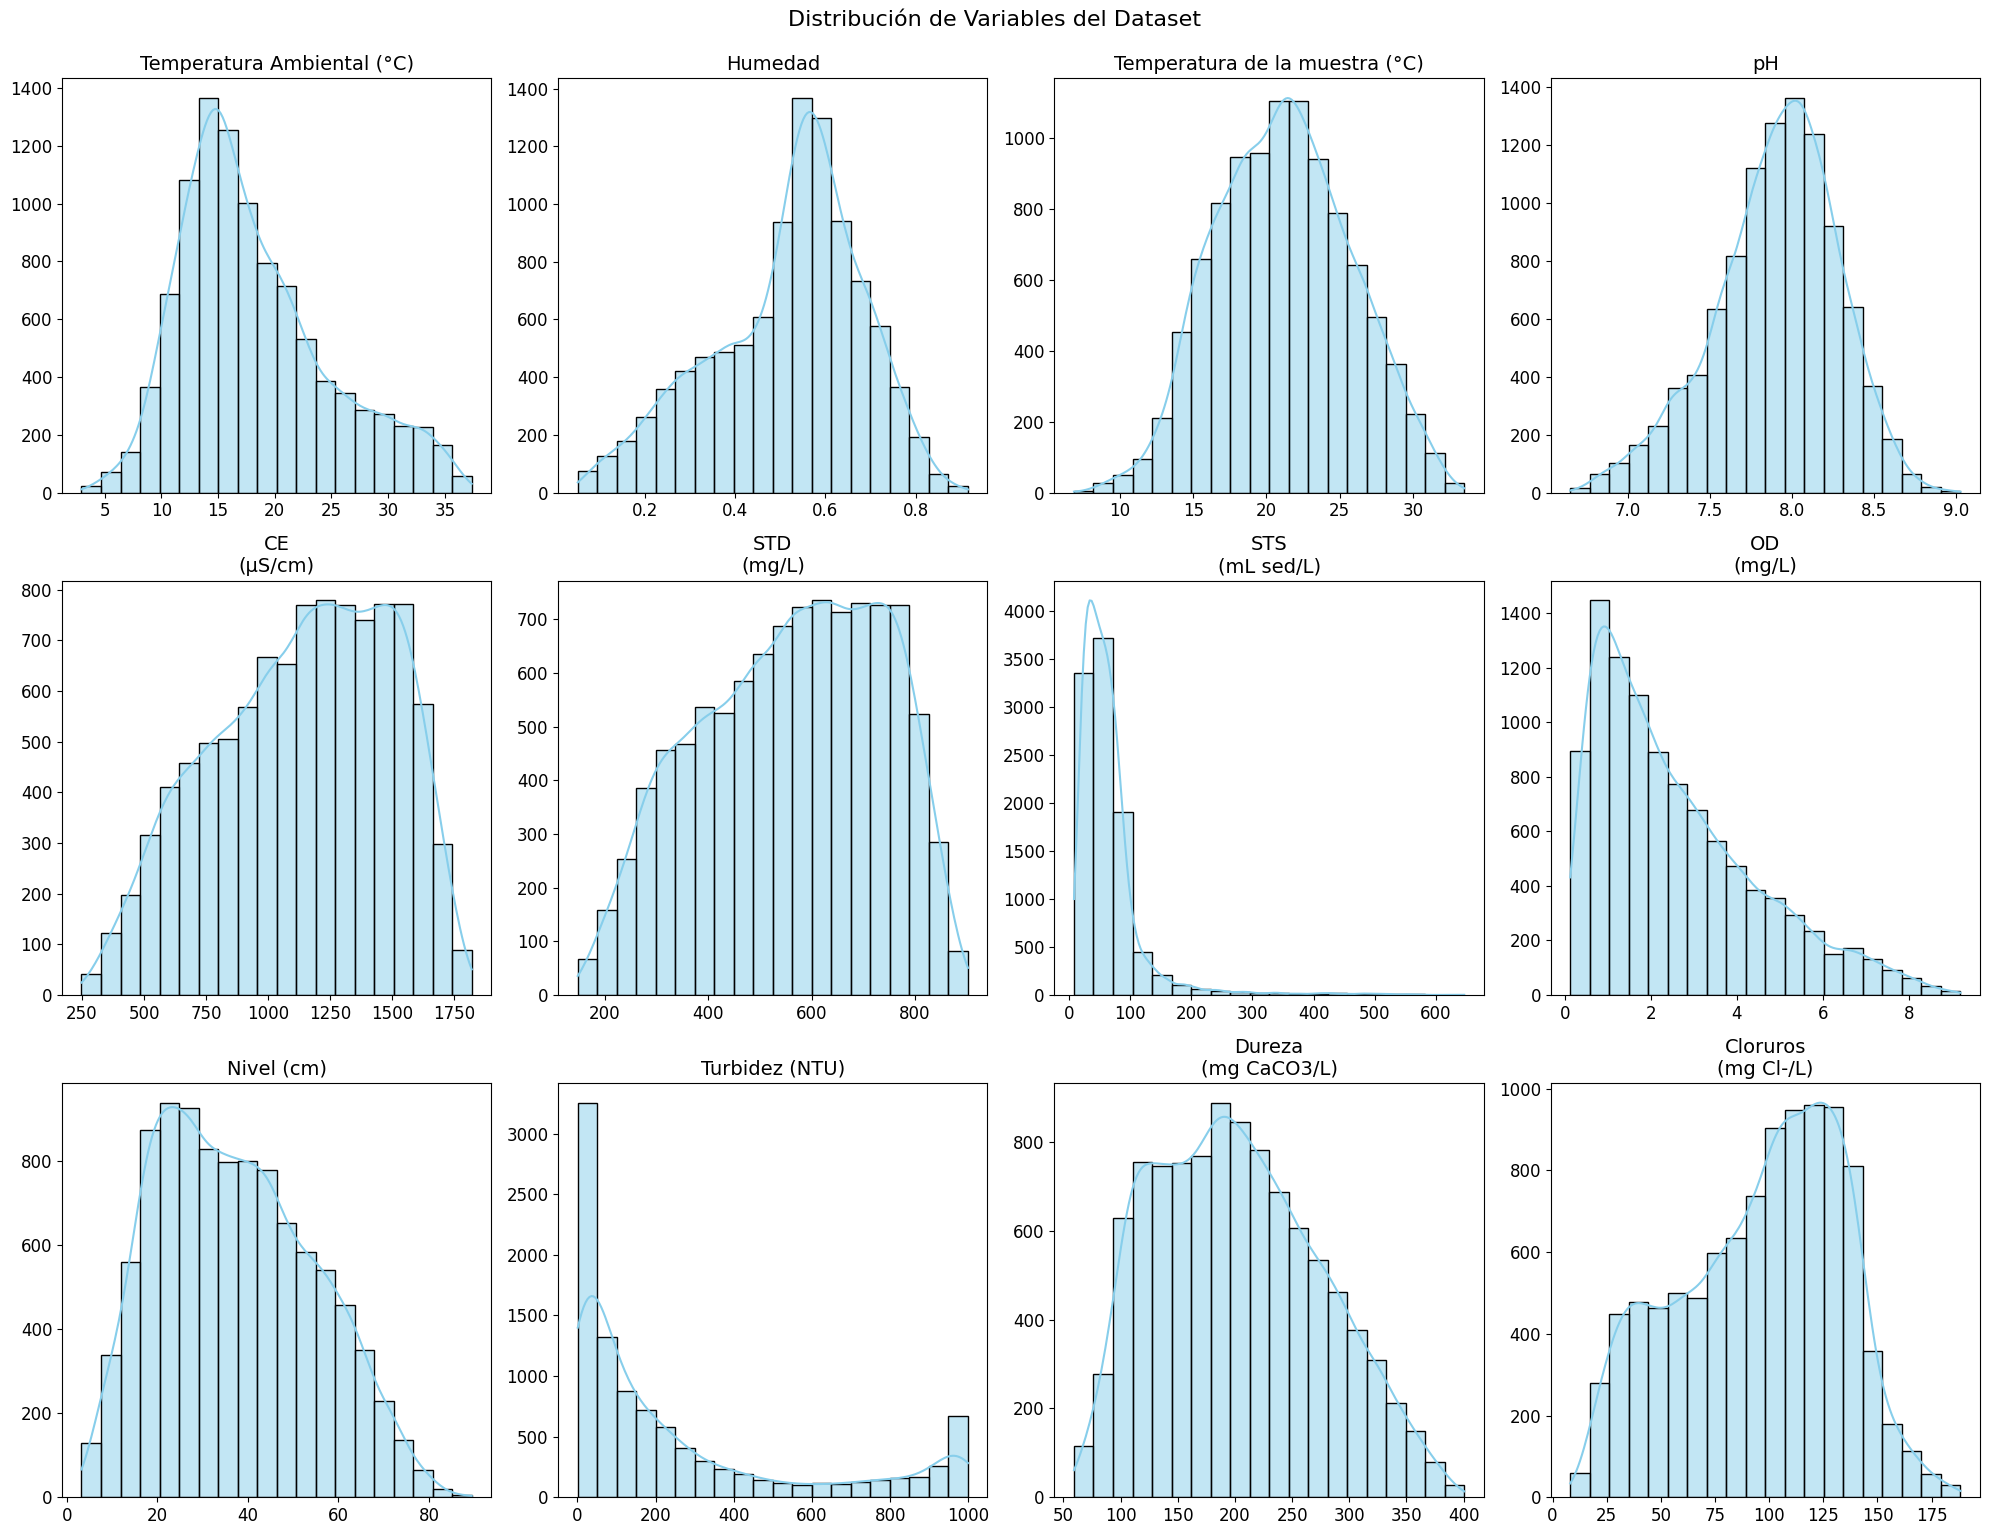

In [39]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_results(df: pd.DataFrame) -> None:
    """
    Función que grafica el histograma de cada columna del dataframe.
    """
    # Determinar el número de columnas en los datos
    n_cols = len(df.columns)

    # Calcular el número de filas necesarias para los subplots
    n_rows = int(np.ceil(n_cols / 4))

    # Crear una figura y una cuadrícula de subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(20, 5 * n_rows))

    # Aplanar la matriz de ejes para un indexado más fácil
    axes_flat = axes.flatten() if n_rows > 1 else axes

    # Eliminar cualquier subplot sobrante
    for i in range(n_cols, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    # Crear histogramas
    for i, col in enumerate(df.columns):
        ax = axes_flat[i]
        sns.histplot(df[col], bins=20, color='skyblue', kde=True, ax=ax)  # Ajuste del número de bins a 100
        ax.set_title(f'{col}', fontsize=14)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

    # Mejorar la disposición
    plt.tight_layout()
    plt.suptitle('Distribución de Variables del Dataset', fontsize=16, y=1.02)
    plt.show()

# Llamada a la función con el DataFrame generado
plot_results(gen_df)


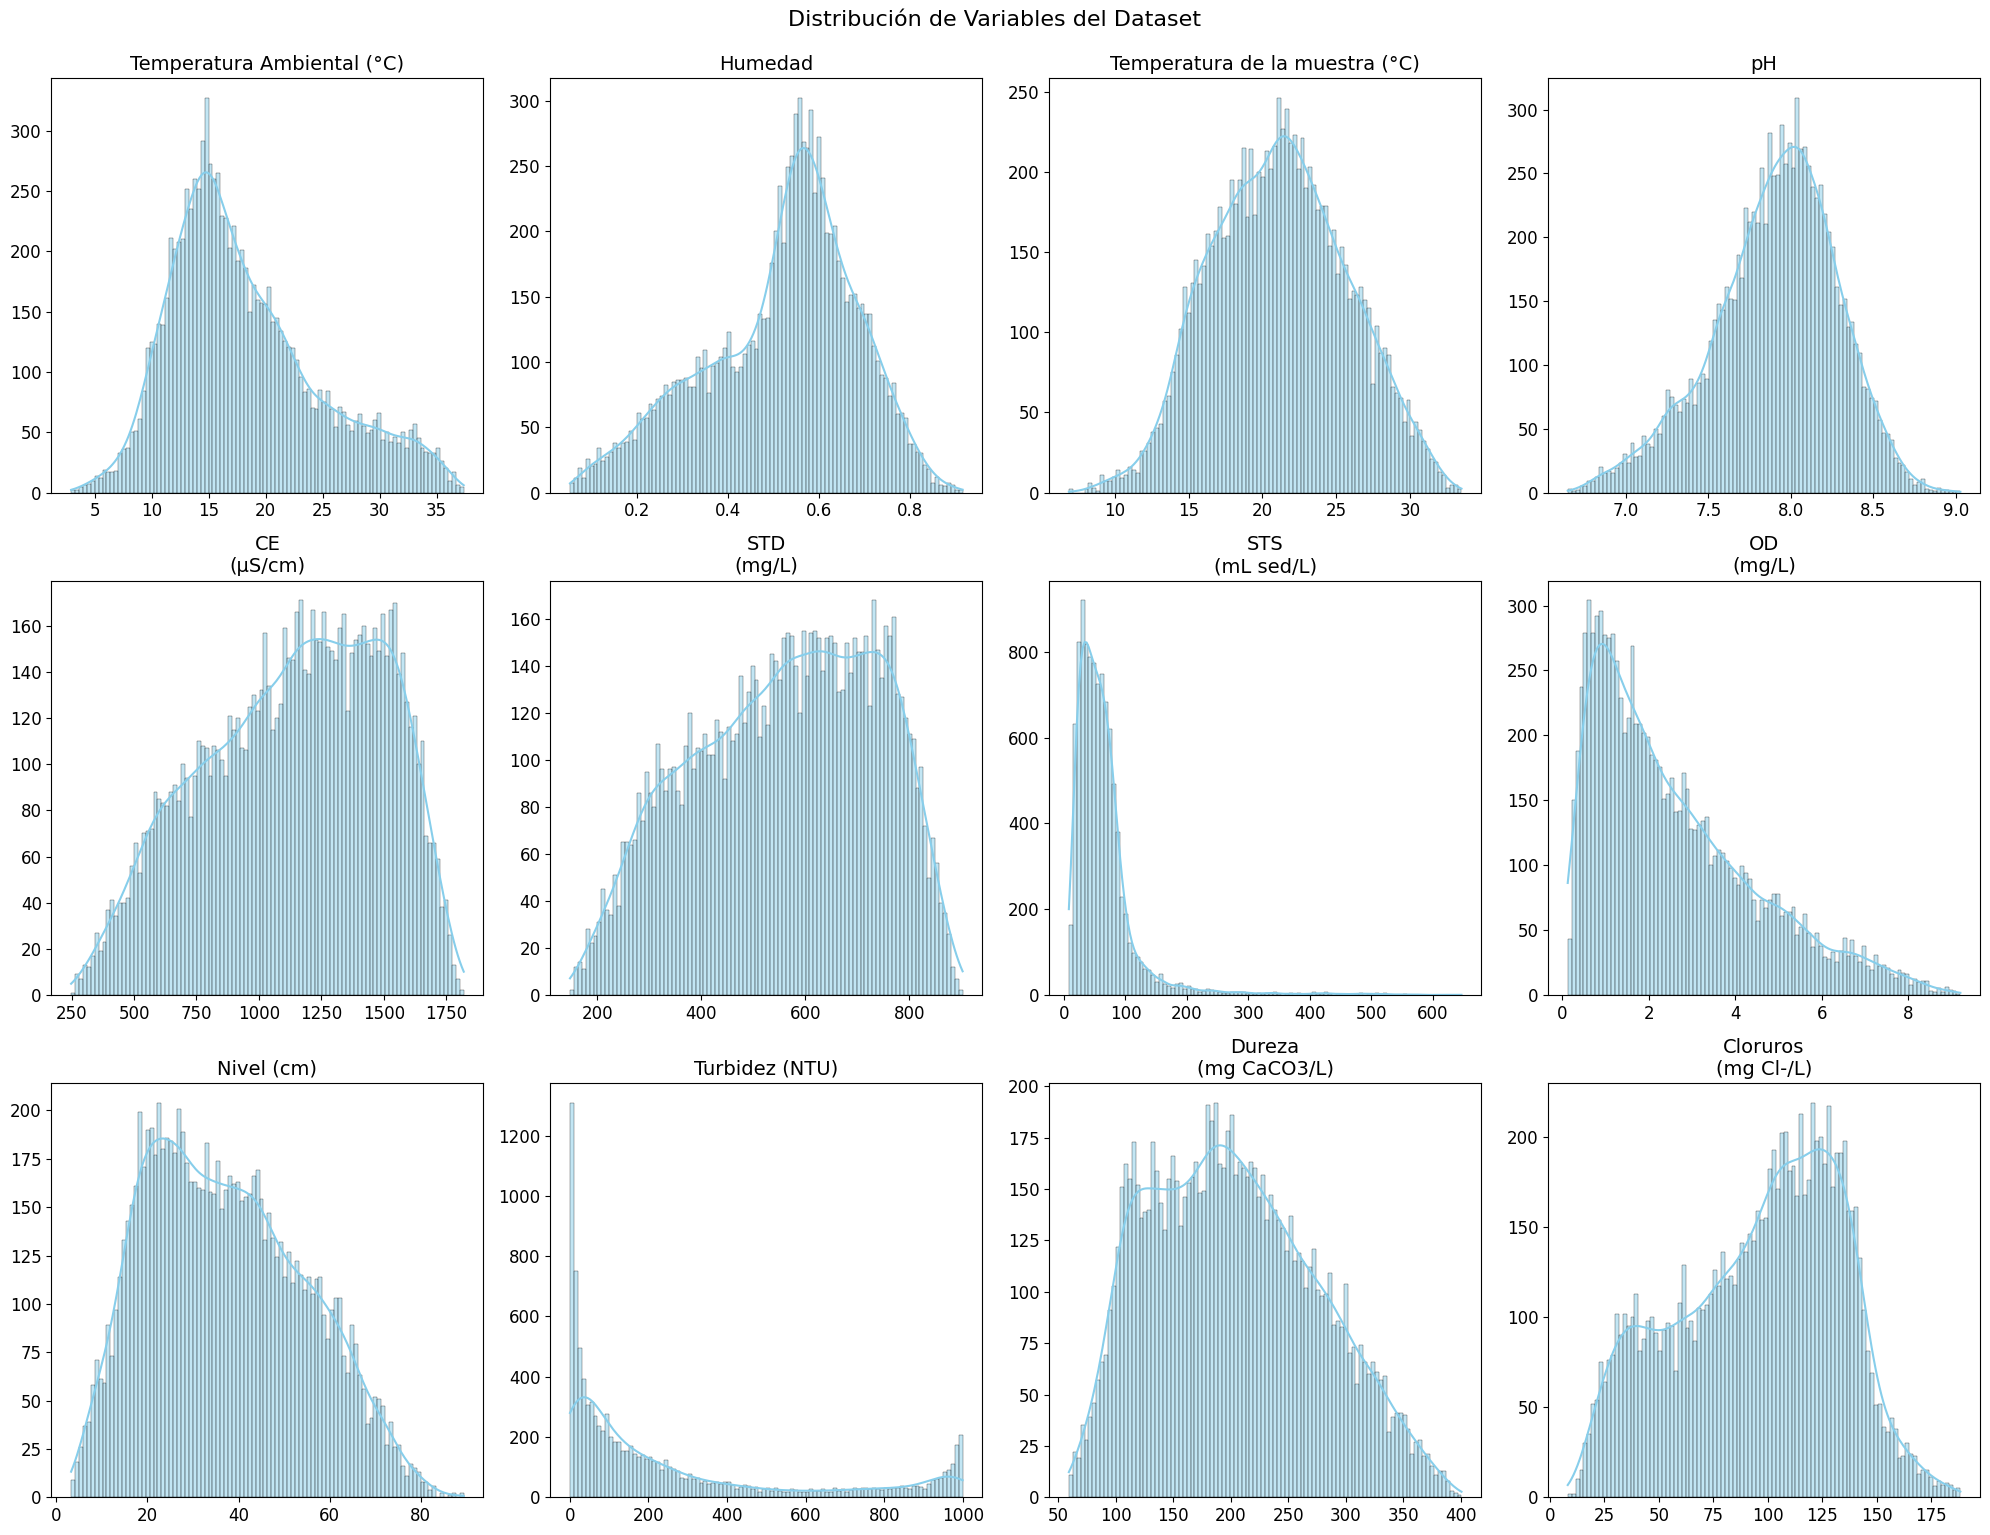

In [40]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_results(df: pd.DataFrame) -> None:
    """
    Función que grafica el histograma de cada columna del dataframe.
    """
    # Determinar el número de columnas en los datos
    n_cols = len(df.columns)

    # Calcular el número de filas necesarias para los subplots
    n_rows = int(np.ceil(n_cols / 4))

    # Crear una figura y una cuadrícula de subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(20, 5 * n_rows))

    # Aplanar la matriz de ejes para un indexado más fácil
    axes_flat = axes.flatten() if n_rows > 1 else axes

    # Eliminar cualquier subplot sobrante
    for i in range(n_cols, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    # Crear histogramas
    for i, col in enumerate(df.columns):
        ax = axes_flat[i]
        sns.histplot(df[col], bins=100, color='skyblue', kde=True, ax=ax)  # Ajuste del número de bins a 100
        ax.set_title(f'{col}', fontsize=14)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

    # Mejorar la disposición
    plt.tight_layout()
    plt.suptitle('Distribución de Variables del Dataset', fontsize=16, y=1.02)
    plt.show()

# Llamada a la función con el DataFrame generado
plot_results(gen_df)


In [41]:
min_max_info(df_sin_nulos)


,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),12.80,30.50,17.50,4.966244
1,Humedad,0.19,0.87,0.53,0.152159
2,Temperatura de la muestra (°C),15.10,28.10,20.05,3.470633
3,pH,7.30,8.70,8.00,0.276488
4,CE\n(µS/cm),200.00,1710.00,1330.00,296.218678
5,STD\n(mg/L),140.00,850.00,655.00,146.845744
6,STS\n(mL sed/L),1.00,620.00,50.00,67.352935
7,OD\n(mg/L),0.00,9.12,1.67,1.755272
8,Nivel (cm),10.00,70.00,35.00,12.640534
9,Turbidez (NTU),1.06,1000.00,64.45,220.822212


In [42]:
min_max_info(gen_df)

,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),2.939056,37.381207,16.733013,6.625093
1,Humedad,0.051690,0.915697,0.545657,0.166324
2,Temperatura de la muestra (°C),6.857704,33.510574,21.148266,4.580567
3,pH,6.648129,9.026964,7.941579,0.376586
4,CE\n(µS/cm),248.035812,1820.595703,1170.158325,352.784027
5,STD\n(mg/L),147.238815,902.824768,574.375549,174.136063
6,STS\n(mL sed/L),7.910023,646.548218,53.316635,55.582642
7,OD\n(mg/L),0.122241,9.200686,2.088544,1.875842
8,Nivel (cm),3.229292,89.433937,35.619957,17.173229
9,Turbidez (NTU),0.773420,999.090820,123.430191,311.279510


In [43]:
colors = encoder.predict(dataset)
color_max = colors.max()
color_min = colors.min()

colored_dataset = df_sin_nulos.copy() #copio el dataset original y lo coloreo con el clsificador (encoder)
#print(colors.shape)


def color_row(row, color_vector):
    #print(color_vector)
    color_vector_normalized = (color_vector - color_min)/(color_max - color_min)
    color_rgb = tuple((color_vector_normalized*255).astype(np.int16))
    color_hex = '#{:02X}{:02X}{:02X}'.format(color_rgb[0], color_rgb[1],255)
    return [f'background-color: {color_hex};' for _ in row.index]

# Create an iterator for the colors
color_iterator = iter(colors)

# Apply colors to each row
styled_df = colored_dataset.style.apply(lambda row: color_row(row, next(color_iterator)), axis=1)
styled_df.to_excel("colored_dataset_variacional.xlsx", engine='openpyxl')


6/6 [==============================] - 0s 1ms/step


ValueError: too many values to unpack (expected 2)

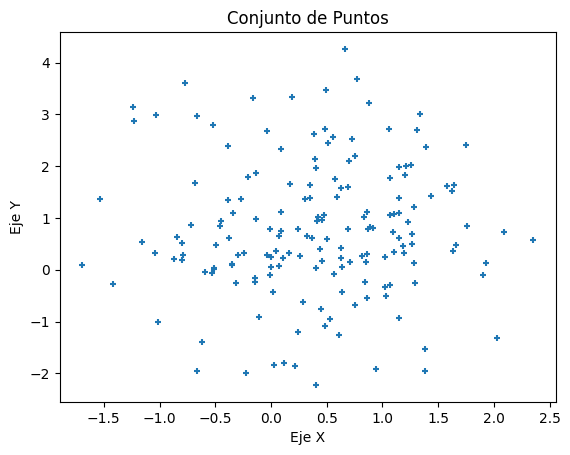

In [44]:
import matplotlib.pyplot as plt


# Dibujamos los puntos
plt.scatter(colors.T[0], colors.T[1], s=20, marker='+')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Conjunto de Puntos')

# Añadimos índices a cada punto
for i, (xi, yi) in enumerate(colors):
    plt.annotate(str(i), (xi, yi), textcoords="offset points", xytext=(0,10), ha='center', fontsize=6)

plt.show()



### Justificación Matemática

Un Variational Autoencoder (VAE) no solo aprende a mapear los datos a un espacio latente y a reconstruirlos, sino que también trata de hacer que la distribución de esos puntos en el espacio latente siga una distribución normal multivariada, típicamente con media cero y varianza unitaria.

#### ¿Por qué es válido muestrear cerca de la media (0,0) con una cierta desviación estándar?

1. **Distribución Aproximada**: El VAE intenta que la distribución latente \( q(z|x) \) se aproxime a una distribución normal estándar \( p(z) \), donde \( z \) es la variable latente y \( x \) son tus datos. Esto se logra mediante la divergencia KL en la función de pérdida. La Divergencia Kullback-Leibler (KL) es una medida de cuán diferente es una distribución de probabilidad PP con respecto a otra distribución QQ.

2. **Densidad de Probabilidad**: En una distribución normal, la máxima densidad de probabilidad está en la media. Esto significa que los puntos muestreados cerca de la media son, en teoría, "más probables" o "más representativos" del conjunto de datos original.

3. **Varianza Controlada**: Al añadirse un vector de desviación estándar, se esta controlando cuánto nos alejamos de la media. Esto permite muestrear puntos que son plausibles pero que también introducen variabilidad.

#### Cautelas

1. **Interpolación vs Extrapolación**: Muestrear dentro de la "nube" de puntos latentes es generalmente seguro (interpolación). Pero si te alejás demasiado, podés entrar en el terreno de la extrapolación, que es más riesgoso y podría generar puntos no representativos.

2. **Validación**: Sería muy útil validar los puntos generados con expertos en química para asegurarte de que son plausibles.

3. **Estadísticas Descriptivas**: Además, podrían se estadísticas descriptivas y hacer comparaciones gráficas (e.g., histogramas, boxplots) entre los datos originales y los generados para evaluar cuán bien los datos generados representan al conjunto original.


